In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import shap

from sklearn.model_selection import train_test_split

import optuna
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

In [106]:
data = pd.read_excel(r"telecom_churn.xlsx")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,7602-MVRMB,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.45,8058.85,No
7791,5908-QMGOE,Male,1,No,No,15.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),74.20,1133.90,Yes
7792,1197-BVMVG,Female,1,No,No,4.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,294.45,No
7793,7516-GMHUV,Male,1,Yes,No,50.0,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),105.05,5163.30,No


In [107]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7795,7043,9871-ELEYA,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7795,2,Male,3928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7795.0,NaN,NaN,NaN,0.165619,0.371762,0.0,0.0,0.0,0.0,1.0
Partner,7795,2,No,4077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7795,2,No,5500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7709.0,NaN,NaN,NaN,31.835387,24.358809,0.0,9.0,28.0,54.0,72.0
PhoneService,7795,2,Yes,7030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7795,3,No,3740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7795,3,Fiber optic,3527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7795,3,No,4039,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
data.drop(['customerID'], axis=1, inplace=True)

In [109]:
data['Churn'] = np.where(data['Churn']=='Yes', 1, 0)
data.Churn.value_counts()

Churn
0    5625
1    2170
Name: count, dtype: int64

In [110]:
data_lr_knn_rf = data.copy()
data_xgb_lgbm_cb_cbc = data.copy()

In [111]:
data_lr_knn_rf.isnull().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure               86
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup        196
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges         11
Churn                 0
dtype: int64

In [112]:
for i in data_lr_knn_rf.columns:
    if i in ['tenure']:
        data_lr_knn_rf[i] = data_lr_knn_rf[i].fillna(0, inplace=True)
    elif not pd.api.types.is_numeric_dtype(data_lr_knn_rf[i]):
        data_lr_knn_rf[i] = data_lr_knn_rf[i].fillna(data_lr_knn_rf[i].mode()[0])
    else:
        data_lr_knn_rf[i] = data_lr_knn_rf[i].fillna(data_lr_knn_rf[i].mean())

C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\3197675287.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_lr_knn_rf[i] = data_lr_knn_rf[i].fillna(0, inplace=True)


In [113]:
data_lr_knn_rf.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [114]:
data_lr = data_lr_knn_rf.copy()
data_knn = data_lr_knn_rf.copy()
data_rf = data_lr_knn_rf.copy()

### LR

In [115]:
for var in data_lr.columns:
    if var == 'Churn':
        continue  

    if pd.api.types.is_numeric_dtype(data_lr[var]):
        
        q1 = data_lr[var].quantile(0.25)
        q2 = data_lr[var].quantile(0.5)
        q3 = data_lr[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        data_lr['category_' + var] = pd.cut(data_lr[var], bins=ranges, duplicates='drop')

        grouped = data_lr.groupby(['category_' + var, 'Churn'])['Churn'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)

    else:

        grouped = data_lr.groupby([var, 'Churn'])['Churn'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[[var, var + '_woe']], how='left', on=var)
        
data_lr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport_woe,StreamingTV_woe,StreamingMovies_woe,Contract_woe,PaperlessBilling_woe,PaymentMethod_woe,category_MonthlyCharges,MonthlyCharges_woe,category_TotalCharges,TotalCharges_woe
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,...,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,-0.813936,"(-inf, 43.4]",0.973049,"(-inf, 385.725]",-0.772430
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,...,-0.655778,-0.29824,-0.307431,1.103053,0.605651,0.444674,"(43.4, 70.75]",0.114972,"(1380.4, 3668.025]",0.224316
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,...,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,0.444674,"(43.4, 70.75]",0.114972,"(-inf, 385.725]",-0.772430
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,...,0.749385,-0.29824,-0.307431,1.103053,0.605651,0.587710,"(-inf, 43.4]",0.973049,"(1380.4, 3668.025]",0.224316
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,...,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,-0.813936,"(43.4, 70.75]",0.114972,"(-inf, 385.725]",-0.772430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,Yes,No,...,0.749385,-0.16842,-0.159784,2.548665,-0.326430,0.587710,"(89.85, inf]",-0.305296,"(3668.025, inf]",0.807893
7791,Male,1,No,No,15.0,Yes,Yes,Fiber optic,No,No,...,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,0.711090,"(70.75, 89.85]",-0.492822,"(385.725, 1380.4]",0.011702
7792,Female,1,No,No,4.0,Yes,Yes,Fiber optic,No,No,...,-0.655778,-0.29824,-0.307431,-0.699862,-0.326430,-0.813936,"(70.75, 89.85]",-0.492822,"(-inf, 385.725]",-0.772430
7793,Male,1,Yes,No,50.0,Yes,Yes,Fiber optic,Yes,No,...,-0.655778,-0.16842,-0.159784,2.548665,-0.326430,0.711090,"(89.85, inf]",-0.305296,"(3668.025, inf]",0.807893


In [116]:
def target_correlation(data, target, threshold=0.1):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    woe_features[target] = data[target] 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target


target_result = target_correlation(data_lr, 'Churn')

target_result

,Variable,Correlation with Target
0,SeniorCitizen_woe,-0.148301
1,Partner_woe,-0.153024
2,Dependents_woe,-0.163836
3,tenure_woe,-0.355827
4,InternetService_woe,-0.326771
5,OnlineSecurity_woe,-0.346364
6,OnlineBackup_woe,-0.287405
7,DeviceProtection_woe,-0.279649
8,TechSupport_woe,-0.341434
9,StreamingTV_woe,-0.185708


In [117]:
def intercorrelation(data, target, threshold=0.7):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    correlated_pairs_set = set()
   
    for var1, var2 in zip(independent_variable_pairs[0], independent_variable_pairs[1]):

        if var1 < var2:
            correlated_pairs_set.add((corr_matrix.index[var1], corr_matrix.columns[var2]))
        else:
            correlated_pairs_set.add((corr_matrix.index[var2], corr_matrix.columns[var1]))
            
   
    
    result_intercorrelated_independent = pd.DataFrame(list(correlated_pairs_set), columns=['Variable 1', 'Variable 2'])
    
    return result_intercorrelated_independent


intercorrelated_result = intercorrelation(data_lr, 'Churn')
intercorrelated_result


,Variable 1,Variable 2
0,InternetService_woe,MonthlyCharges_woe
1,StreamingTV_woe,StreamingMovies_woe
2,tenure_woe,TotalCharges_woe


In [118]:
LR_vars = target_result.Variable.tolist()

LR_vars # variables for Logistic Regression

['SeniorCitizen_woe',
 'Partner_woe',
 'Dependents_woe',
 'tenure_woe',
 'InternetService_woe',
 'OnlineSecurity_woe',
 'OnlineBackup_woe',
 'DeviceProtection_woe',
 'TechSupport_woe',
 'StreamingTV_woe',
 'StreamingMovies_woe',
 'Contract_woe',
 'PaperlessBilling_woe',
 'PaymentMethod_woe',
 'MonthlyCharges_woe',
 'TotalCharges_woe']

### KNN

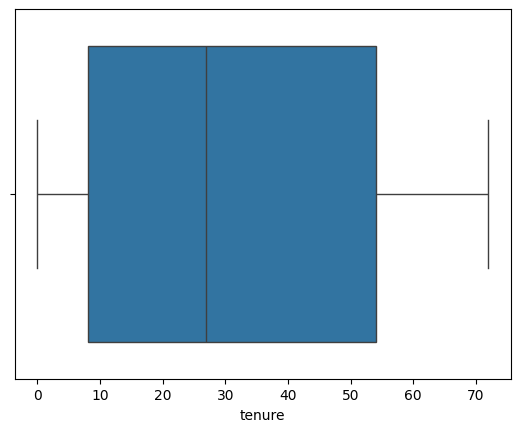

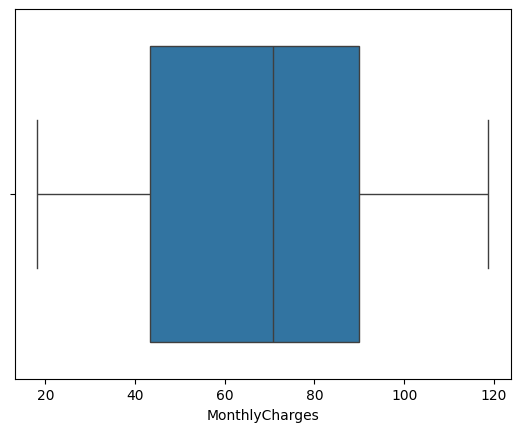

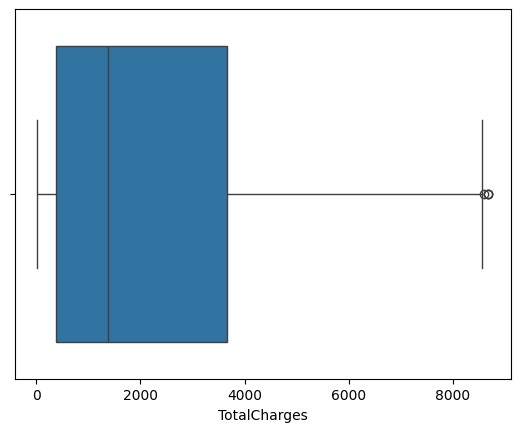

In [119]:
for i in data_knn.columns:
    if pd.api.types.is_numeric_dtype(data_knn[i]) and i!='Churn' and i!='SeniorCitizen':
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [120]:
q1=data_knn.quantile(0.25, numeric_only=True)
q3=data_knn.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

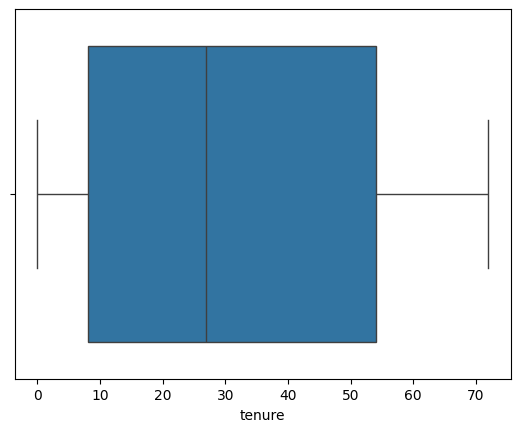

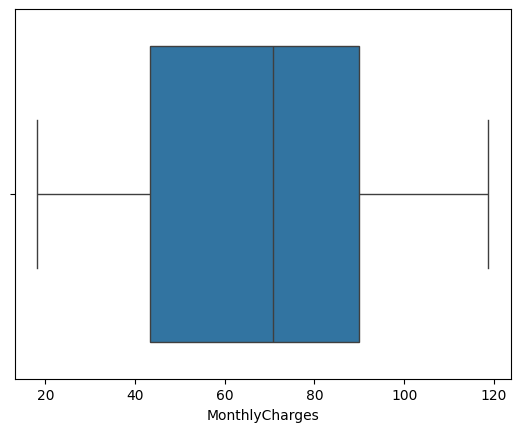

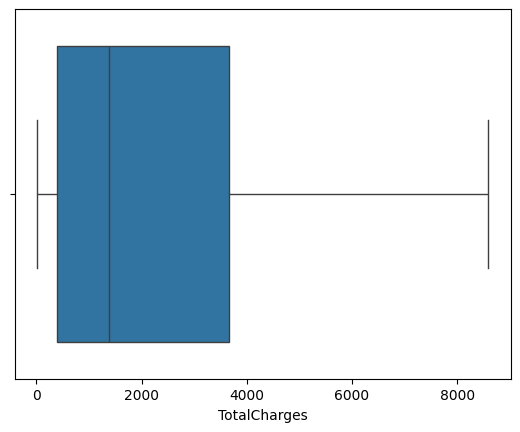

In [121]:
for i in data_knn.columns:
    if pd.api.types.is_numeric_dtype(data_knn[i]) and i!='Churn' and i!='SeniorCitizen':
        data_knn[i] = np.where(data_knn[i] > Upper[i],Upper[i],data_knn[i])
        data_knn[i] = np.where(data_knn[i] < Lower[i],Lower[i],data_knn[i])
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [122]:
def target_correlation(data, target, threshold=0.1):
    corr_matrix = data.corr(method='spearman', numeric_only=True)
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target

target_result = target_correlation(data_knn, 'Churn')

target_result

,Variable,Correlation with Target
0,SeniorCitizen,0.148301
1,tenure,-0.375285
2,MonthlyCharges,0.185910
3,TotalCharges,-0.243797


In [123]:
def intercorrelation(data, target, threshold=0.7):
    corr_matrix = data.drop(columns=[target]).corr(method='spearman', numeric_only=True)
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    result_intercorrelated_independent = pd.DataFrame({
        'Variable 1': corr_matrix.index[independent_variable_pairs[0]],
        'Variable 2': corr_matrix.columns[independent_variable_pairs[1]]
    })
    return result_intercorrelated_independent

intercorrelated_result = intercorrelation(data_knn, 'Churn')

intercorrelated_result

,Variable 1,Variable 2
0,tenure,TotalCharges
1,TotalCharges,tenure


In [124]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data_knn, ['SeniorCitizen', 'tenure', 'MonthlyCharges', 
                                      #'TotalCharges'
                                     ])

vif_result


,VIF,Features
0,1.260254,SeniorCitizen
1,2.561698,tenure
2,2.880962,MonthlyCharges


In [125]:
data_knn.drop(['TotalCharges'], axis=1, inplace = True)
target_result = target_result.drop(target_result.index[3])
data_knn.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Churn'],
      dtype='str')

In [126]:
knn_target_results = target_result.Variable.tolist()

In [127]:
le = LabelEncoder()

for i in data_knn.columns:
    data_knn[i] = le.fit_transform(data_knn[i])
data_knn

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,142,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,498,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,436,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,266,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,729,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,0,0,1,1,72,1,2,1,2,0,2,2,2,2,2,1,0,1477,0
7791,1,1,0,0,15,1,2,1,0,0,0,0,0,0,0,1,1,791,1
7792,0,1,0,0,4,1,2,1,0,0,0,0,0,0,0,1,2,796,0
7793,1,1,1,0,50,1,2,1,2,0,2,0,2,2,2,1,1,1376,0


### RF

In [128]:
le = LabelEncoder()

for i in data_rf.columns:
    data_rf[i] = le.fit_transform(data_rf[i])
data_rf

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,142,74,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,498,3624,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,436,536,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,266,3570,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,729,674,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,0,0,1,1,72,1,2,1,2,0,2,2,2,2,2,1,0,1477,6463,0
7791,1,1,0,0,15,1,2,1,0,0,0,0,0,0,0,1,1,791,2675,1
7792,0,1,0,0,4,1,2,1,0,0,0,0,0,0,0,1,2,796,1120,0
7793,1,1,1,0,50,1,2,1,2,0,2,0,2,2,2,1,1,1376,5470,0


In [129]:
data_xgb_lgbm_cb = data_xgb_lgbm_cb_cbc.copy()
data_cbc = data_xgb_lgbm_cb_cbc.copy()

### XGB, LGBM, CB

In [130]:
le = LabelEncoder()

for i in data_xgb_lgbm_cb.columns:
    data_xgb_lgbm_cb[i] = le.fit_transform(data_xgb_lgbm_cb[i])
data_xgb_lgbm_cb

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,142,74,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,498,3624,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,436,536,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,266,3570,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,729,674,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7790,0,0,1,1,72,1,2,1,2,0,2,2,2,2,2,1,0,1477,6462,0
7791,1,1,0,0,15,1,2,1,0,0,0,0,0,0,0,1,1,791,2675,1
7792,0,1,0,0,4,1,2,1,0,0,0,0,0,0,0,1,2,796,1120,0
7793,1,1,1,0,50,1,2,1,2,0,2,0,2,2,2,1,1,1376,5469,0


### CBC

In [131]:
for i in data_cbc.columns:
    if not pd.api.types.is_numeric_dtype(data_cbc[i]):
        data_cbc[i] = data_cbc[i].fillna('Missing Value')
        
data_cbc.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure              86
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [132]:
output = data['Churn']

In [133]:
inputs_lr = data_lr[LR_vars]
inputs_knn = data_knn[knn_target_results]
inputs_rf = data_rf.drop('Churn', axis=1)
inputs_xgb_lgbm_cb = data_xgb_lgbm_cb.drop('Churn', axis=1)
inputs_cbc = data_cbc.drop('Churn', axis=1)

In [134]:
scaler = StandardScaler()
scaler.fit(inputs_knn) 

inputs_knn_scaled = scaler.transform(inputs_knn)
data_knn_scaled = pd.DataFrame(inputs_knn_scaled, columns=inputs_knn.columns)

data_knn_scaled

,SeniorCitizen,tenure,MonthlyCharges
0,-0.445526,-1.246812,-1.176595
1,-0.445526,0.102899,-0.418037
2,-0.445526,-1.205911,-0.550145
3,-0.445526,0.552802,-0.912378
4,-0.445526,-1.205911,0.074174
...,...,...,...
7790,-0.445526,1.657111,1.667997
7791,2.244539,-0.674207,0.206282
7792,2.244539,-1.124111,0.216936
7793,2.244539,0.757304,1.452789


In [135]:
X_train_lr, X_test_lr, y_train, y_test = train_test_split(inputs_lr, output, test_size=0.3, random_state=42)
X_train_knn, X_test_knn, y_train, y_test = train_test_split(data_knn_scaled, output, test_size=0.3, random_state=42)
X_train_rf, X_test_rf, y_train, y_test = train_test_split(inputs_rf, output, test_size=0.3, random_state=42)
X_train_xgb_lgbm_cb, X_test_xgb_lgbm_cb, y_train, y_test = train_test_split(inputs_xgb_lgbm_cb, output, test_size=0.3, random_state=42)
X_train_cbc, X_test_cbc, y_train, y_test = train_test_split(inputs_cbc, output, test_size=0.3, random_state=42)

In [136]:
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1]

        roc_prob_train = roc_auc_score(y_train, y_prob_train)
        gini_prob_train = roc_prob_train * 2 - 1
        confusion_matrix_result_train = confusion_matrix(y_train, y_pred_train)
        classification_report_result_train = classification_report(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train Gini prob is', gini_prob_train * 100)
        print(classification_report_result_train)
        print(confusion_matrix_result_train)

        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]

        roc_prob_test = roc_auc_score(y_test, y_prob_test)
        gini_prob_test = roc_prob_test * 2 - 1
        confusion_matrix_result_test = confusion_matrix(y_test, y_pred_test)
        classification_report_result_test = classification_report(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test Gini prob is', gini_prob_test * 100)
        print(classification_report_result_test)
        print(confusion_matrix_result_test)

        return [gini_prob_train, gini_prob_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [137]:
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
cat_cols

C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\2445868527.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object']).columns.tolist()


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [138]:
models = []

lr_model = LogisticRegression()
knn_model_def = KNeighborsClassifier()
rf_model_def = RandomForestClassifier(random_state=42)
xgb_model_def = XGBClassifier(random_state=42)
lgb_model_def = LGBMClassifier(random_state=42)
catboost_model_def = CatBoostClassifier(random_state=42)
catboost_model_custom = CatBoostClassifier(cat_features=['gender', 'Partner', 'Dependents', 'PhoneService',
 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], random_state=42)

models.extend([
    ('LogReg', lr_model),
    ('KNN', knn_model_def),
    ('RF', rf_model_def),
    ('XGBoost', xgb_model_def),
    ('CatBoost', catboost_model_def),
    ('CatBoost_Custom', catboost_model_custom)
])

In [139]:
gini_df = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models:
    if model_name == 'LogReg':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_lr, y_train, X_test_lr, y_test)
    elif model_name == 'KNN':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
    elif model_name == 'RF':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_rf, y_train, X_test_rf, y_test)
    elif model_name == 'CatBoost_Custom':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_cbc, y_train, X_test_cbc, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb, y_train, X_test_xgb_lgbm_cb, y_test)

    if gini_prob is not None:
        gini_df = pd.concat([gini_df, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted = gini_df.sort_values(by='Test Gini', ascending=False)

gini_df_sorted

Model Performance for LogReg
Train Gini prob is 68.37925376647198
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      3964
           1       0.66      0.53      0.59      1492

    accuracy                           0.80      5456
   macro avg       0.75      0.71      0.73      5456
weighted avg       0.79      0.80      0.79      5456

[[3558  406]
 [ 700  792]]
Model Performance for LogReg
Test Gini prob is 69.70176476125019
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1661
           1       0.68      0.55      0.61       678

    accuracy                           0.79      2339
   macro avg       0.76      0.72      0.73      2339
weighted avg       0.79      0.79      0.79      2339

[[1489  172]
 [ 308  370]]
Model Performance for KNN
Train Gini prob is 80.51768868881597
              precision    recall  f1-score   support

           0       0.87      0.91      0.89

,Model,Train Gini,Test Gini
2,RF,0.99994,0.731531
5,CatBoost_Custom,0.795106,0.719214
4,CatBoost,0.893494,0.717515
3,XGBoost,0.980774,0.70642
0,LogReg,0.683793,0.697018
1,KNN,0.805177,0.574401


In [140]:
gini_df_sorted

,Model,Train Gini,Test Gini
2,RF,0.99994,0.731531
5,CatBoost_Custom,0.795106,0.719214
4,CatBoost,0.893494,0.717515
3,XGBoost,0.980774,0.70642
0,LogReg,0.683793,0.697018
1,KNN,0.805177,0.574401


In [141]:
# KNN

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50), 
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),  
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),  
    'leaf_size': trial.suggest_int('leaf_size', 10, 100),  
    'p': trial.suggest_int('p', 1, 2),  
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan']) 
}

    knn_clf = KNeighborsClassifier(**param)

    roc = cross_val_score(knn_clf, X_train_knn, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsClassifier(**best_params)

[I 2026-04-04 14:54:11,966] A new study created in memory with name: no-name-b7acee53-a27d-4f4b-802c-0875c06a3a36
[I 2026-04-04 14:54:17,324] Trial 0 finished with value: 0.8097561390258818 and parameters: {'n_neighbors': 24, 'weights': 'uniform', 'algorithm': 'kd_tree', 'leaf_size': 37, 'p': 1, 'metric': 'euclidean'}. Best is trial 0 with value: 0.8097561390258818.
[I 2026-04-04 14:54:20,092] Trial 1 finished with value: 0.82718456468146 and parameters: {'n_neighbors': 31, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 69, 'p': 2, 'metric': 'manhattan'}. Best is trial 1 with value: 0.82718456468146.


Best trial:
  Value: 0.827
  Params:  {'n_neighbors': 31, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 69, 'p': 2, 'metric': 'manhattan'}


In [142]:
# RF

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
    'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),  
    'max_depth': trial.suggest_int('max_depth', 10, 50),  
    'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),  
}

    rf_clf = RandomForestClassifier(**param)

    roc = cross_val_score(rf_clf, X_train_rf, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestClassifier(**best_params)

[I 2026-04-04 14:54:20,113] A new study created in memory with name: no-name-97cd98c9-62db-4d36-8d11-29af163fca34
[I 2026-04-04 14:54:22,691] Trial 0 finished with value: 0.848784440960055 and parameters: {'n_estimators': 355, 'max_features': 'sqrt', 'max_depth': 33, 'min_samples_split': 33, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.848784440960055.
[I 2026-04-04 14:54:23,708] Trial 1 finished with value: 0.8464172279654703 and parameters: {'n_estimators': 146, 'max_features': 'sqrt', 'max_depth': 38, 'min_samples_split': 84, 'min_samples_leaf': 22}. Best is trial 0 with value: 0.848784440960055.


Best trial:
  Value: 0.849
  Params:  {'n_estimators': 355, 'max_features': 'sqrt', 'max_depth': 33, 'min_samples_split': 33, 'min_samples_leaf': 13}


In [143]:
# XGBoost

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train_xgb_lgbm_cb, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBClassifier(**best_params)

[I 2026-04-04 14:54:23,716] A new study created in memory with name: no-name-c9ae4594-6619-40ec-8df1-76a86ee42f9a
[I 2026-04-04 14:54:24,308] Trial 0 finished with value: 0.8397972524260077 and parameters: {'n_estimators': 29, 'learning_rate': 0.013074332681455397, 'max_depth': 9, 'subsample': 0.7426860392732704, 'colsample_bytree': 0.7026814704107224, 'gamma': 9}. Best is trial 0 with value: 0.8397972524260077.
[I 2026-04-04 14:54:24,935] Trial 1 finished with value: 0.8416822980664597 and parameters: {'n_estimators': 578, 'learning_rate': 0.3145482978174705, 'max_depth': 7, 'subsample': 0.5371605223009076, 'colsample_bytree': 0.7323072253244922, 'gamma': 10}. Best is trial 1 with value: 0.8416822980664597.


Best trial:
  Value: 0.842
  Params:  {'n_estimators': 578, 'learning_rate': 0.3145482978174705, 'max_depth': 7, 'subsample': 0.5371605223009076, 'colsample_bytree': 0.7323072253244922, 'gamma': 10}


Params:  {'n_estimators': 578, 'learning_rate': 0.3145482978174705, 'max_depth': 7, 'subsample': 0.5371605223009076, 'colsample_bytree': 0.7323072253244922, 'gamma': 10}

In [144]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train_xgb_lgbm_cb, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostClassifier(**best_params)

[I 2026-04-04 14:54:24,944] A new study created in memory with name: no-name-638a93bc-b72b-40ef-b932-03b28f402484
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\1271488672.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\1271488672.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-04 14:54:39,102] Trial 0 finished with value: 0.8397348060914197 and parameters: {'iterations': 453, 'learning_rate': 0.04694694606105816, 'depth': 10, 'l2_leaf_reg': 0.4122443381194304, 'loss_

Best trial:
  Value: 0.843
  Params:  {'iterations': 502, 'learning_rate': 0.021741183117564858, 'depth': 10, 'l2_leaf_reg': 0.74114432102477, 'loss_function': 'Logloss'}


In [145]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train_xgb_lgbm_cb, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMClassifier(**best_params)

[I 2026-04-04 14:54:52,873] A new study created in memory with name: no-name-34193c80-d857-4c59-85f8-bd173a80354c
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\957772737.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-04 14:55:03,810] Trial 0 finished with value: 0.812444240900197 and parameters: {'n_estimators': 931, 'learning_rate': 0.27857030528838056, 'max_depth': 10, 'num_leaves': 55}. Best is trial 0 with value: 0.812444240900197.
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\957772737.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguni

Best trial:
  Value: 0.840
  Params:  {'n_estimators': 38, 'learning_rate': 0.05510566413525061, 'max_depth': 3, 'num_leaves': 56}


In [197]:
models_optimized = []

models_optimized.extend([
    ('KNN Optuna', best_knn_model),
    ('RF Optuna', best_rf_model),
    ('XGBoost Optuna', best_xgb_model),
    ('CatBoost Optuna', best_cb_model),
    ('LightGBM Optuna', best_lgb_model)
])

In [198]:
gini_df_optuna = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models_optimized:
    if model_name == 'KNN Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
    elif model_name == 'RF Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_rf, y_train, X_test_rf, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb, y_train, X_test_xgb_lgbm_cb, y_test)

    if gini_prob is not None:
        gini_df_optuna = pd.concat([gini_df_optuna, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted_optuna = gini_df_optuna.sort_values(by='Test Gini', ascending=False)

gini_df_sorted_optuna


Model Performance for KNN Optuna
Train Gini prob is 99.8967077693883
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3964
           1       0.99      0.96      0.97      1492

    accuracy                           0.99      5456
   macro avg       0.99      0.98      0.98      5456
weighted avg       0.99      0.99      0.99      5456

[[3951   13]
 [  62 1430]]
Model Performance for KNN Optuna
Test Gini prob is 68.53807369836203
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1661
           1       0.69      0.56      0.62       678

    accuracy                           0.80      2339
   macro avg       0.76      0.73      0.74      2339
weighted avg       0.79      0.80      0.79      2339

[[1489  172]
 [ 298  380]]
Model Performance for RF Optuna
Train Gini prob is 79.12697183498676
              precision    recall  f1-score   support

           0       0.85      0

,Model,Train Gini,Test Gini
3,CatBoost Optuna,0.99177,0.71999
1,RF Optuna,0.79127,0.713716
2,XGBoost Optuna,0.712503,0.707609
4,LightGBM Optuna,0.701646,0.703804
0,KNN Optuna,0.998967,0.685381


In [199]:
final_review = pd.concat([gini_df_sorted,gini_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test Gini', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted['Gini_gap'] = (final_review_sorted['Train Gini'] - final_review_sorted['Test Gini']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Gini_gap'],
    ascending=[True]
).reset_index(drop=True)

final_review_sorted

,Model,Train Gini,Test Gini,Gini_gap
0,LightGBM Optuna,0.701646,0.703804,0.002158
1,XGBoost Optuna,0.712503,0.707609,0.004894
2,LogReg,0.683793,0.697018,0.013225
3,CatBoost_Custom,0.795106,0.719214,0.075892
4,RF Optuna,0.79127,0.713716,0.077554
5,CatBoost,0.893494,0.717515,0.175979
6,KNN,0.805177,0.574401,0.230776
7,RF,0.99994,0.731531,0.268408
8,CatBoost Optuna,0.99177,0.71999,0.27178
9,XGBoost,0.980774,0.70642,0.274354


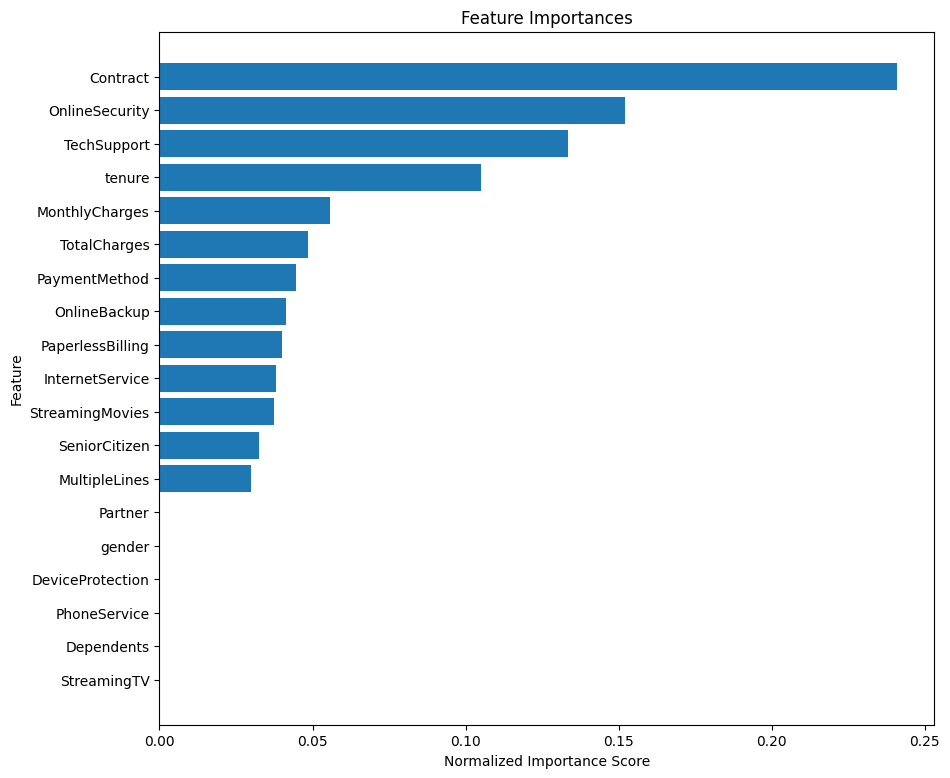

In [150]:
importances = best_xgb_model.feature_importances_


importances = importances / importances.sum()

importance_df = pd.DataFrame({
        'Feature':  X_train_xgb_lgbm_cb.columns,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importances")
plt.xlabel("Normalized Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [151]:
importance_df

,Feature,Importance
14,Contract,0.241046
8,OnlineSecurity,0.152081
11,TechSupport,0.133330
4,tenure,0.105120
17,MonthlyCharges,0.055573
18,TotalCharges,0.048532
16,PaymentMethod,0.044734
9,OnlineBackup,0.041312
15,PaperlessBilling,0.039985
7,InternetService,0.038165


In [152]:
important_features_df = importance_df[importance_df['Importance'] > 0.01]

print("Features with Importance > 1%:")
important_features_df

Features with Importance > 1%:


,Feature,Importance
14,Contract,0.241046
8,OnlineSecurity,0.152081
11,TechSupport,0.133330
4,tenure,0.105120
17,MonthlyCharges,0.055573
18,TotalCharges,0.048532
16,PaymentMethod,0.044734
9,OnlineBackup,0.041312
15,PaperlessBilling,0.039985
7,InternetService,0.038165


In [153]:
important_features_df.Feature.tolist()

['Contract',
 'OnlineSecurity',
 'TechSupport',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'PaymentMethod',
 'OnlineBackup',
 'PaperlessBilling',
 'InternetService',
 'StreamingMovies',
 'SeniorCitizen',
 'MultipleLines']

SHAP Values Summary (Selected Features)


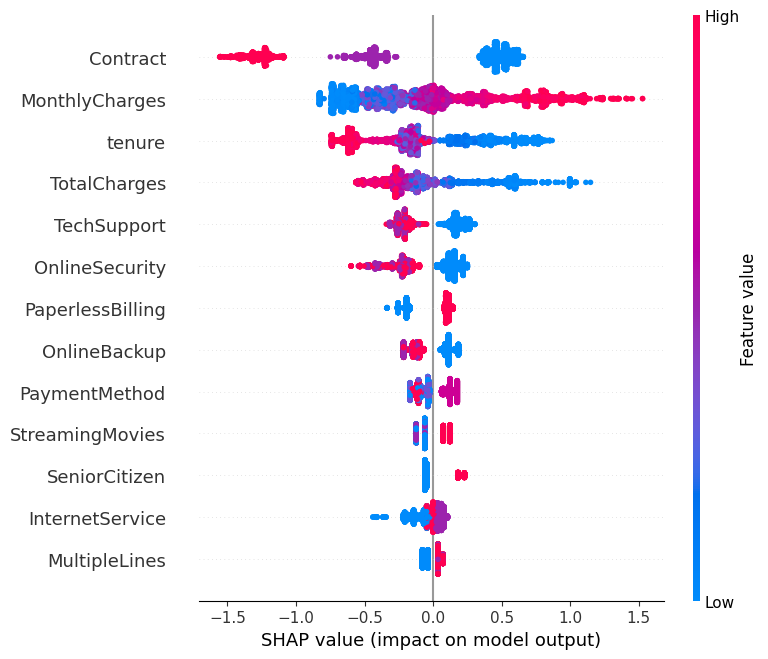

In [156]:
selected_features = ['Contract',
 'OnlineSecurity',
 'TechSupport',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'PaymentMethod',
 'OnlineBackup',
 'PaperlessBilling',
 'InternetService',
 'StreamingMovies',
 'SeniorCitizen',
 'MultipleLines']


explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_train_xgb_lgbm_cb)


shap_df = pd.DataFrame(shap_values, columns=X_train_xgb_lgbm_cb.columns)
shap_selected = shap_df[selected_features]
X_selected = X_train_xgb_lgbm_cb[selected_features]


print("SHAP Values Summary (Selected Features)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_selected.values, X_selected, show=False)
plt.tight_layout()
plt.show()

In [157]:
new_inputs = important_features_df['Feature'].tolist()

new_inputs

['Contract',
 'OnlineSecurity',
 'TechSupport',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'PaymentMethod',
 'OnlineBackup',
 'PaperlessBilling',
 'InternetService',
 'StreamingMovies',
 'SeniorCitizen',
 'MultipleLines']

In [160]:
fin_input = data_xgb_lgbm_cb[important_features_df['Feature'].tolist()]
fin_output = data['Churn']

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(fin_input, fin_output, test_size=0.3, random_state=42)

In [161]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
         # Fraction of the training data to be randomly sampled for each boosting round (to reduce overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # Fraction of features (columns) to be randomly sampled for each tree (adds diversity)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # Controls how much gain is needed to make a split; higher = fewer splits (simpler model)
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    
    auc = cross_val_score(xgb_clf, X_train_fin, y_train_fin, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model_fin = XGBClassifier(**best_params)

[I 2026-04-04 15:08:41,133] A new study created in memory with name: no-name-e6033ad4-0ade-42ba-bb12-adc10be7ea60
[I 2026-04-04 15:08:46,040] Trial 0 finished with value: 0.8433904858778938 and parameters: {'n_estimators': 240, 'learning_rate': 0.12529180911685156, 'max_depth': 9, 'subsample': 0.9206432429343232, 'colsample_bytree': 0.9153220259743604, 'gamma': 1}. Best is trial 0 with value: 0.8433904858778938.
[I 2026-04-04 15:08:50,264] Trial 1 finished with value: 0.8460772511384672 and parameters: {'n_estimators': 815, 'learning_rate': 0.12118874650029847, 'max_depth': 6, 'subsample': 0.8436817315749441, 'colsample_bytree': 0.5882266044757539, 'gamma': 4}. Best is trial 1 with value: 0.8460772511384672.


Best trial:
  Value: 0.846
  Params:  {'n_estimators': 815, 'learning_rate': 0.12118874650029847, 'max_depth': 6, 'subsample': 0.8436817315749441, 'colsample_bytree': 0.5882266044757539, 'gamma': 4}


In [162]:
fin_results = train_and_evaluate_model('XBG opitimized for selected features', best_xgb_model_fin, X_train_fin, y_train_fin, X_test_fin, y_test_fin)

Model Performance for XBG opitimized for selected features
Train Gini prob is 74.8358044112833
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      3964
           1       0.70      0.57      0.63      1492

    accuracy                           0.82      5456
   macro avg       0.78      0.74      0.76      5456
weighted avg       0.81      0.82      0.81      5456

[[3602  362]
 [ 636  856]]
Model Performance for XBG opitimized for selected features
Test Gini prob is 71.2530568534788
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1661
           1       0.71      0.56      0.62       678

    accuracy                           0.80      2339
   macro avg       0.77      0.73      0.75      2339
weighted avg       0.80      0.80      0.80      2339

[[1505  156]
 [ 301  377]]


In [163]:
fin_results

[0.748358044112833, 0.712530568534788]

### Voting

In [186]:
lr_model_vot = LogisticRegression()

In [187]:
inputs_vot = data_knn.drop('Churn', axis=1)

X_train, X_test, y_train, y_test = train_test_split(inputs_vot, output, test_size=0.3, random_state=42)

In [188]:
# RF

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
    'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),  
    'max_depth': trial.suggest_int('max_depth', 10, 50),  
    'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),  
}

    rf_clf = RandomForestClassifier(**param)

    roc = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model_vot = RandomForestClassifier(**best_params)

[I 2026-04-04 15:21:34,483] A new study created in memory with name: no-name-c981e6a5-2f23-4157-97b9-ef0baec2fd2d
[I 2026-04-04 15:21:35,695] Trial 0 finished with value: 0.8450939772209953 and parameters: {'n_estimators': 181, 'max_features': 'sqrt', 'max_depth': 39, 'min_samples_split': 35, 'min_samples_leaf': 28}. Best is trial 0 with value: 0.8450939772209953.
[I 2026-04-04 15:21:38,362] Trial 1 finished with value: 0.8448564297014508 and parameters: {'n_estimators': 437, 'max_features': 'sqrt', 'max_depth': 45, 'min_samples_split': 53, 'min_samples_leaf': 30}. Best is trial 0 with value: 0.8450939772209953.


Best trial:
  Value: 0.845
  Params:  {'n_estimators': 181, 'max_features': 'sqrt', 'max_depth': 39, 'min_samples_split': 35, 'min_samples_leaf': 28}


In [189]:
# XGBoost

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model_vot = XGBClassifier(**best_params)

[I 2026-04-04 15:21:38,400] A new study created in memory with name: no-name-10d9567b-ea4e-46fb-b1e1-14d14af52dec
[I 2026-04-04 15:21:39,070] Trial 0 finished with value: 0.8387869663592262 and parameters: {'n_estimators': 748, 'learning_rate': 0.11080942325762184, 'max_depth': 3, 'subsample': 0.7011062186672268, 'colsample_bytree': 0.8122392017860373, 'gamma': 2}. Best is trial 0 with value: 0.8387869663592262.
[I 2026-04-04 15:21:39,526] Trial 1 finished with value: 0.8457343133116525 and parameters: {'n_estimators': 332, 'learning_rate': 0.07506155765620862, 'max_depth': 10, 'subsample': 0.7118231298568235, 'colsample_bytree': 0.8460448962372423, 'gamma': 6}. Best is trial 1 with value: 0.8457343133116525.


Best trial:
  Value: 0.846
  Params:  {'n_estimators': 332, 'learning_rate': 0.07506155765620862, 'max_depth': 10, 'subsample': 0.7118231298568235, 'colsample_bytree': 0.8460448962372423, 'gamma': 6}


In [190]:
# Catboost

def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model_vot = CatBoostClassifier(**best_params)

[I 2026-04-04 15:21:39,687] A new study created in memory with name: no-name-7aafecec-320c-4397-9de6-6b7c018ace12
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\3280906625.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\3280906625.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-04 15:21:45,702] Trial 0 finished with value: 0.8191554817073006 and parameters: {'iterations': 742, 'learning_rate': 0.4845938138201322, 'depth': 7, 'l2_leaf_reg': 6.263558212078794, 'loss_fun

Best trial:
  Value: 0.847
  Params:  {'iterations': 272, 'learning_rate': 0.050695299356732615, 'depth': 4, 'l2_leaf_reg': 0.44440198264830355, 'loss_function': 'Logloss'}


In [191]:
# LGBM

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=2)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model_vot = LGBMClassifier(**best_params)

[I 2026-04-04 15:21:47,334] A new study created in memory with name: no-name-65328255-a6a0-40ab-8702-d10748ad41db
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\3819203744.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-04 15:21:47,845] Trial 0 finished with value: 0.8446755980783536 and parameters: {'n_estimators': 370, 'learning_rate': 0.010385137867806388, 'max_depth': 3, 'num_leaves': 30}. Best is trial 0 with value: 0.8446755980783536.
C:\Users\Asus\AppData\Local\Temp\ipykernel_12668\3819203744.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_lo

Best trial:
  Value: 0.845
  Params:  {'n_estimators': 370, 'learning_rate': 0.010385137867806388, 'max_depth': 3, 'num_leaves': 30}


In [192]:
voting_clf_hard = VotingClassifier(
    estimators=[
        ('lr', lr_model_vot),
        ('rf', best_rf_model_vot),
        ('xgb', best_xgb_model_vot),
        ('cat', best_cb_model_vot),
        ('lgb', best_lgb_model_vot)
    ],
    voting='hard' 
)

In [193]:
from sklearn.metrics import classification_report

def train_and_evaluate_model_voting_hard(model_name, model, X_train, y_train, X_test, y_test):
    try:
        print(f"\nTraining {model_name}...")
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Classification reports as dicts
        train_report_dict = classification_report(y_train, y_train_pred, output_dict=True)
        test_report_dict = classification_report(y_test, y_test_pred, output_dict=True)

        # Convert to DataFrames
        train_report_df = pd.DataFrame(train_report_dict).transpose()
        test_report_df = pd.DataFrame(test_report_dict).transpose()

        # Add model info
        train_report_df["Dataset"] = "Train"
        train_report_df["Model"] = model_name

        test_report_df["Dataset"] = "Test"
        test_report_df["Model"] = model_name

        # Combine into one dataframe
        final_df = pd.concat([train_report_df, test_report_df], axis=0)

        return final_df

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [194]:
train_and_evaluate_model_voting_hard('Voting model', voting_clf_hard, X_train, y_train, X_test, y_test)


Training Voting model...


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0:	learn: 0.6620383	total: 5.53ms	remaining: 1.5s
1:	learn: 0.6368120	total: 9.56ms	remaining: 1.29s
2:	learn: 0.6141557	total: 14.2ms	remaining: 1.27s
3:	learn: 0.5937309	total: 19.1ms	remaining: 1.28s
4:	learn: 0.5773568	total: 23.4ms	remaining: 1.25s
5:	learn: 0.5624271	total: 27.3ms	remaining: 1.21s
6:	learn: 0.5499059	total: 31.5ms	remaining: 1.19s
7:	learn: 0.5389361	total: 35.5ms	remaining: 1.17s
8:	learn: 0.5288959	total: 39.5ms	remaining: 1.16s
9:	learn: 0.5182588	total: 43.5ms	remaining: 1.14s
10:	learn: 0.5087565	total: 47.8ms	remaining: 1.13s
11:	learn: 0.5009372	total: 51.8ms	remaining: 1.12s
12:	learn: 0.4938329	total: 55.9ms	remaining: 1.11s
13:	learn: 0.4874975	total: 60.3ms	remaining: 1.11s
14:	learn: 0.4811438	total: 64.7ms	remaining: 1.11s
15:	learn: 0.4758457	total: 69.5ms	remaining: 1.11s
16:	learn: 0.4716539	total: 74ms	remaining: 1.11s
17:	learn: 0.4678868	total: 78.7ms	remaining: 1.11s
18:	learn: 0.4654701	total: 83ms	remaining: 1.1s
19:	learn: 0.4623476	total: 

,precision,recall,f1-score,support,Dataset,Model
0,0.841407,0.911453,0.875030,3964.000000,Train,Voting model
1,0.697935,0.543566,0.611153,1492.000000,Train,Voting model
accuracy,0.810850,0.810850,0.810850,0.810850,Train,Voting model
macro avg,0.769671,0.727509,0.743092,5456.000000,Train,Voting model
weighted avg,0.802173,0.810850,0.802870,5456.000000,Train,Voting model
0,0.832415,0.909091,0.869065,1661.000000,Test,Voting model
1,0.712381,0.551622,0.621779,678.000000,Test,Voting model
accuracy,0.805472,0.805472,0.805472,0.805472,Test,Voting model
macro avg,0.772398,0.730357,0.745422,2339.000000,Test,Voting model
weighted avg,0.797621,0.805472,0.797385,2339.000000,Test,Voting model


In [195]:
voting_clf_soft = VotingClassifier(
    estimators=[
        ('lr', lr_model_vot),
        ('rf', best_rf_model_vot),
        ('xgb', best_xgb_model_vot),
        ('cat', best_cb_model_vot),
        ('lgb', best_lgb_model_vot)
    ],
    voting='soft' 
)

train_and_evaluate_model('Voting model', voting_clf_soft, X_train, y_train, X_test, y_test)

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0:	learn: 0.6620383	total: 3.62ms	remaining: 981ms
1:	learn: 0.6368120	total: 7.79ms	remaining: 1.05s
2:	learn: 0.6141557	total: 11.4ms	remaining: 1.02s
3:	learn: 0.5937309	total: 14.9ms	remaining: 1s
4:	learn: 0.5773568	total: 18.5ms	remaining: 988ms
5:	learn: 0.5624271	total: 22.5ms	remaining: 998ms
6:	learn: 0.5499059	total: 26.1ms	remaining: 988ms
7:	learn: 0.5389361	total: 29.6ms	remaining: 978ms
8:	learn: 0.5288959	total: 32.9ms	remaining: 962ms
9:	learn: 0.5182588	total: 36.2ms	remaining: 949ms
10:	learn: 0.5087565	total: 40.2ms	remaining: 954ms
11:	learn: 0.5009372	total: 43.6ms	remaining: 945ms
12:	learn: 0.4938329	total: 47ms	remaining: 937ms
13:	learn: 0.4874975	total: 50.7ms	remaining: 935ms
14:	learn: 0.4811438	total: 54.4ms	remaining: 931ms
15:	learn: 0.4758457	total: 58ms	remaining: 928ms
16:	learn: 0.4716539	total: 61.4ms	remaining: 921ms
17:	learn: 0.4678868	total: 64.8ms	remaining: 914ms
18:	learn: 0.4654701	total: 68.5ms	remaining: 912ms
19:	learn: 0.4623476	total: 7

[0.733316673114329, 0.7177873797460037]

### Stacking

In [200]:
estimators = [
    ('KNN Optuna', best_knn_model),
    ('RF Optuna', best_rf_model),
    ('CatBoost Optuna', best_cb_model),
    ('LightGBM Optuna', best_lgb_model)    
]

estimators

[('KNN Optuna',
  KNeighborsClassifier(algorithm='ball_tree', leaf_size=69, metric='manhattan',
                       n_neighbors=31, weights='distance')),
 ('RF Optuna',
  RandomForestClassifier(max_depth=33, min_samples_leaf=13, min_samples_split=33,
                         n_estimators=355)),
 ('CatBoost Optuna',
  CatBoostClassifier(depth=10, iterations=502, l2_leaf_reg=0.74114432102477, learning_rate=0.021741183117564858, loss_function='Logloss')),
 ('LightGBM Optuna',
  LGBMClassifier(learning_rate=0.05510566413525061, max_depth=3, n_estimators=38,
                 num_leaves=56))]

In [201]:
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator= best_xgb_model,
    passthrough=True,   # if True, raw features are also passed to final estimator
    cv=5,                
    stack_method='predict_proba'  # ensures probabilities are passed
)

stack_clf

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('KNN Optuna', ...), ('RF Optuna', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","XGBClassifier...ree=None, ...)"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",True
,"verbose verbose: int, default=0Verbosity level.",0
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",31
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` pa

In [202]:
train_and_evaluate_model('Stacking model', stack_clf, X_train, y_train, X_test, y_test)

0:	learn: 0.6764633	total: 11.9ms	remaining: 5.98s
1:	learn: 0.6606769	total: 24ms	remaining: 6s
2:	learn: 0.6462864	total: 32.4ms	remaining: 5.38s
3:	learn: 0.6325633	total: 44ms	remaining: 5.48s
4:	learn: 0.6195351	total: 61.4ms	remaining: 6.1s
5:	learn: 0.6053794	total: 79.3ms	remaining: 6.55s
6:	learn: 0.5929888	total: 97ms	remaining: 6.86s
7:	learn: 0.5814258	total: 115ms	remaining: 7.09s
8:	learn: 0.5712049	total: 126ms	remaining: 6.92s
9:	learn: 0.5607091	total: 144ms	remaining: 7.07s
10:	learn: 0.5496102	total: 161ms	remaining: 7.21s
11:	learn: 0.5413785	total: 173ms	remaining: 7.07s
12:	learn: 0.5342587	total: 181ms	remaining: 6.82s
13:	learn: 0.5258607	total: 199ms	remaining: 6.93s
14:	learn: 0.5198111	total: 205ms	remaining: 6.66s
15:	learn: 0.5107704	total: 223ms	remaining: 6.78s
16:	learn: 0.5025113	total: 242ms	remaining: 6.91s
17:	learn: 0.4945525	total: 266ms	remaining: 7.16s
18:	learn: 0.4866971	total: 285ms	remaining: 7.25s
19:	learn: 0.4800948	total: 304ms	remaining:

[0.9999563768284534, 0.7703279646372887]